In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, classification_report, confusion_matrix)

In [4]:
df = pd.read_csv(r"C:\Users\Spandan\Downloads\housing.csv")
print("Shape:", df.shape)
print(df.head())
print(df.describe())

Shape: (20640, 10)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
          longitude      latitude  housing_median_age   

In [5]:
print("Missing Before:\n", df.isnull().sum())

df.fillna(df.median(numeric_only=True), inplace=True)
for col in df.select_dtypes('object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing After:\n", df.isnull().sum())

Missing Before:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Missing After:
 longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


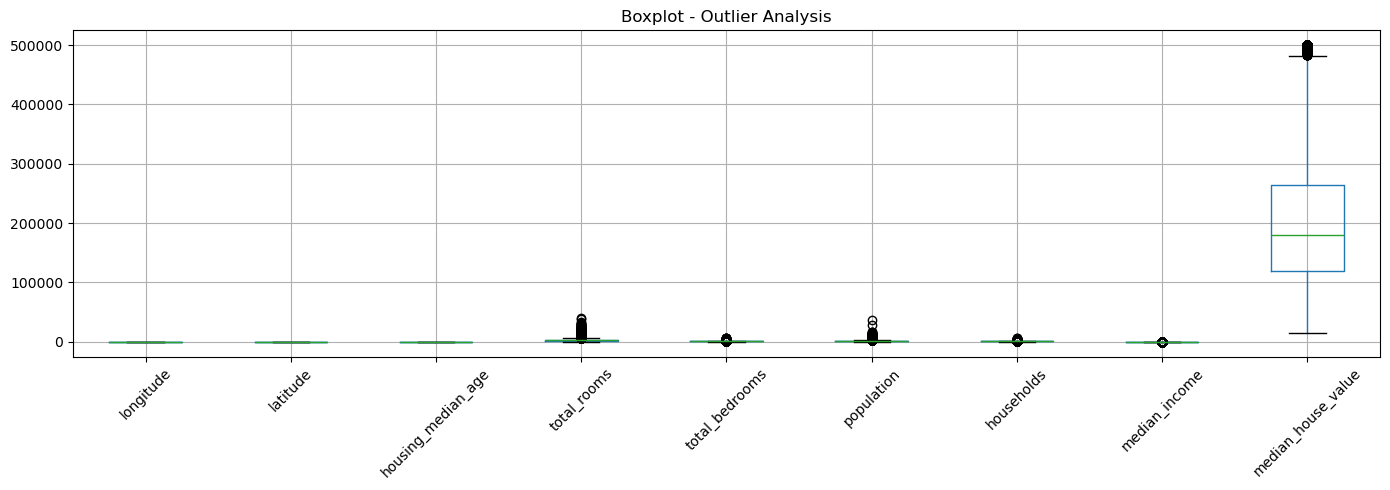

In [6]:
df.select_dtypes(include=np.number).boxplot(figsize=(14, 5), rot=45)
plt.title("Boxplot - Outlier Analysis")
plt.tight_layout()
plt.show()

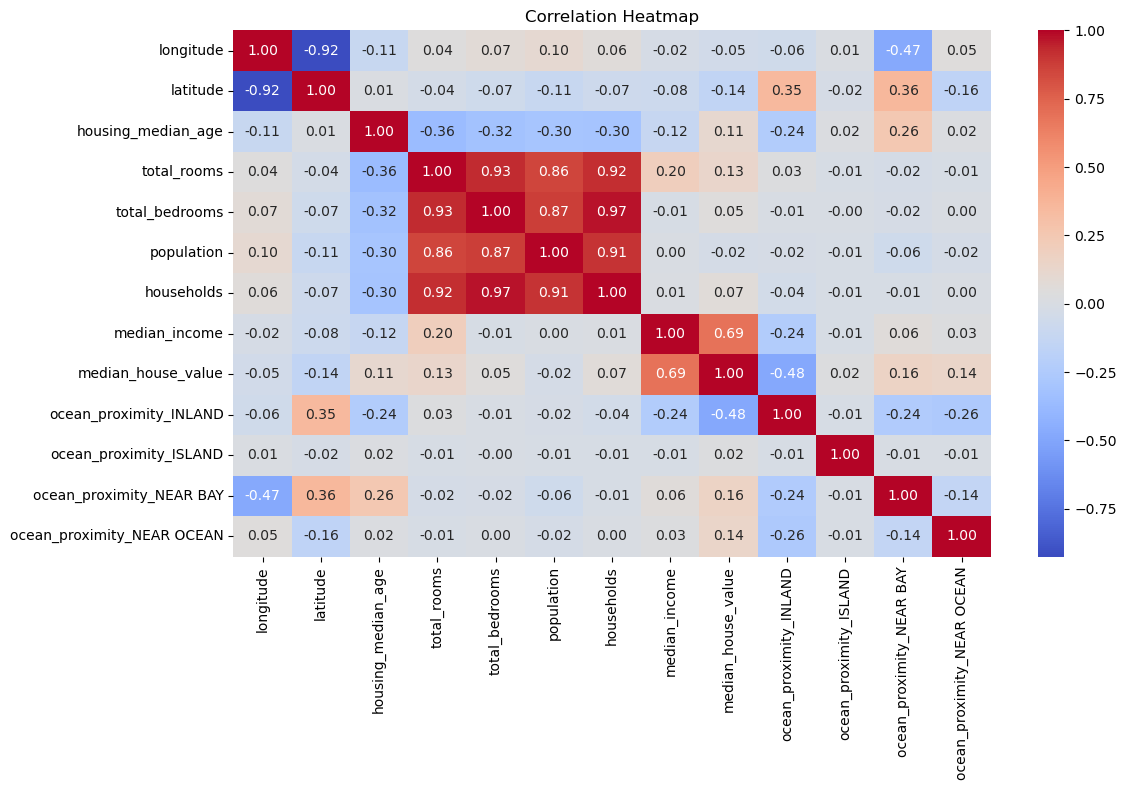

In [7]:
df = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [8]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

results = []


Simple LR → MAE:62990.87  RMSE:84209.01  R²:0.4589


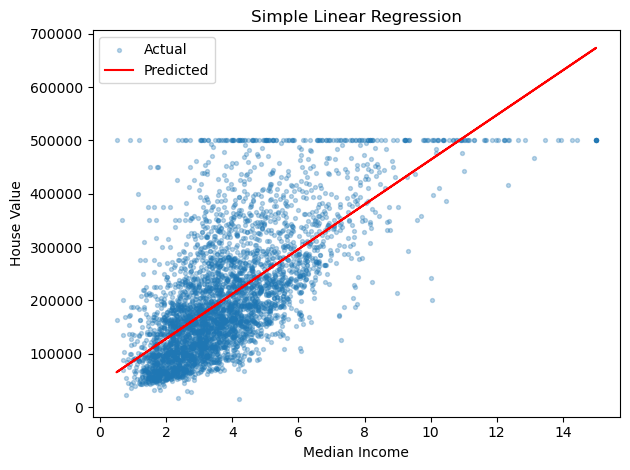

In [9]:
slr = LinearRegression()
slr.fit(X_train[['median_income']], y_train)
y_pred_slr = slr.predict(X_test[['median_income']])

mae  = mean_absolute_error(y_test, y_pred_slr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_slr))
r2   = r2_score(y_test, y_pred_slr)
print(f"Simple LR → MAE:{mae:.2f}  RMSE:{rmse:.2f}  R²:{r2:.4f}")
results.append({'Model': 'Simple LR', 'MAE': mae, 'RMSE': rmse, 'R2': r2})

plt.scatter(X_test[['median_income']], y_test, alpha=0.3, s=8, label='Actual')
plt.plot(X_test[['median_income']], y_pred_slr, color='red', label='Predicted')
plt.title("Simple Linear Regression")
plt.xlabel("Median Income"); plt.ylabel("House Value")
plt.legend(); plt.tight_layout(); plt.show()

In [10]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)
y_pred_mlr = mlr.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_mlr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlr))
r2   = r2_score(y_test, y_pred_mlr)
print(f"Multiple LR → MAE:{mae:.2f}  RMSE:{rmse:.2f}  R²:{r2:.4f}")
results.append({'Model': 'Multiple LR', 'MAE': mae, 'RMSE': rmse, 'R2': r2})

Multiple LR → MAE:50670.74  RMSE:70060.52  R²:0.6254


In [11]:
top_features = ['median_income', 'housing_median_age', 'households']

poly_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('lr',     LinearRegression())
])
poly_pipe.fit(X_train[top_features], y_train)
y_pred_poly = poly_pipe.predict(X_test[top_features])

mae  = mean_absolute_error(y_test, y_pred_poly)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2   = r2_score(y_test, y_pred_poly)
print(f"Polynomial LR → MAE:{mae:.2f}  RMSE:{rmse:.2f}  R²:{r2:.4f}")
results.append({'Model': 'Polynomial LR (deg=2)', 'MAE': mae, 'RMSE': rmse, 'R2': r2})



Polynomial LR → MAE:57605.74  RMSE:77706.44  R²:0.5392


In [12]:
for alpha in [0.1, 1.0, 100.0]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_sc, y_train)
    y_pred = ridge.predict(X_test_sc)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"Ridge α={alpha} → MAE:{mae:.2f}  RMSE:{rmse:.2f}  R²:{r2:.4f}")
    results.append({'Model': f'Ridge (α={alpha})', 'MAE': mae, 'RMSE': rmse, 'R2': r2})


Ridge α=0.1 → MAE:50670.48  RMSE:70060.21  R²:0.6254
Ridge α=1.0 → MAE:50668.12  RMSE:70057.42  R²:0.6255
Ridge α=100.0 → MAE:50510.98  RMSE:69891.66  R²:0.6272


In [13]:
for alpha in [0.01, 1.0, 100.0]:
    lasso = Lasso(alpha=alpha, max_iter=5000)
    lasso.fit(X_train_sc, y_train)
    y_pred = lasso.predict(X_test_sc)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"LASSO α={alpha} → MAE:{mae:.2f}  RMSE:{rmse:.2f}  R²:{r2:.4f}")
    results.append({'Model': f'LASSO (α={alpha})', 'MAE': mae, 'RMSE': rmse, 'R2': r2})

LASSO α=0.01 → MAE:50670.73  RMSE:70060.52  R²:0.6254
LASSO α=1.0 → MAE:50670.13  RMSE:70059.85  R²:0.6254
LASSO α=100.0 → MAE:50616.92  RMSE:70004.08  R²:0.6260


Logistic Regression → Accuracy: 0.8328
              precision    recall  f1-score   support

   Low Price       0.83      0.84      0.83      2077
  High Price       0.84      0.83      0.83      2051

    accuracy                           0.83      4128
   macro avg       0.83      0.83      0.83      4128
weighted avg       0.83      0.83      0.83      4128



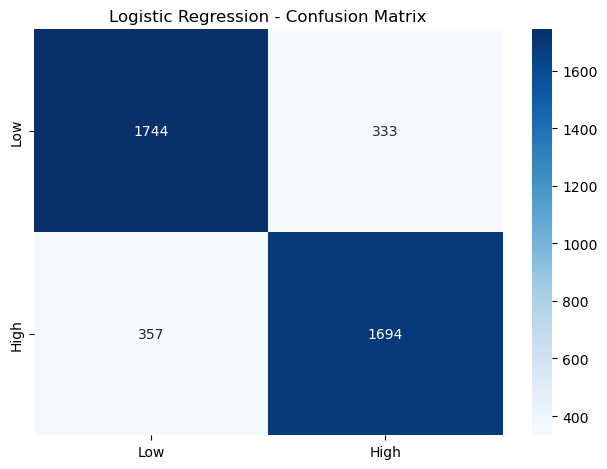

In [14]:
threshold   = y.median()
y_bin_train = (y_train > threshold).astype(int)
y_bin_test  = (y_test  > threshold).astype(int)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_sc, y_bin_train)
y_pred_log = log_reg.predict(X_test_sc)

acc = accuracy_score(y_bin_test, y_pred_log)
print(f"Logistic Regression → Accuracy: {acc:.4f}")
print(classification_report(y_bin_test, y_pred_log, target_names=['Low Price', 'High Price']))

cm = confusion_matrix(y_bin_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout(); plt.show()

In [15]:
print("Sample Predictions (Multiple LR):")
print(pd.DataFrame({'Actual': y_test.iloc[:5].values,
                    'Predicted': mlr.predict(X_test.iloc[:5]).round(2)}))

Sample Predictions (Multiple LR):
     Actual  Predicted
0   47700.0   54055.45
1   45800.0  124225.34
2  500001.0  255489.38
3  218600.0  268002.43
4  278000.0  262769.43


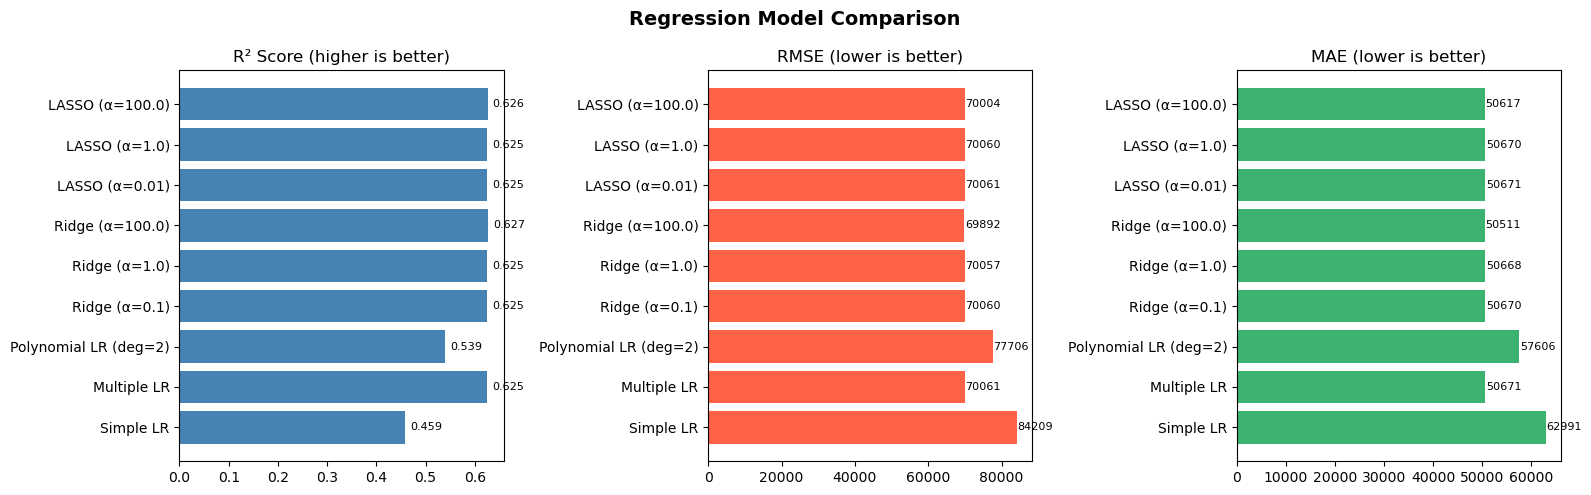

In [16]:
reg_df = pd.DataFrame([r for r in results if r['RMSE'] is not None])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Regression Model Comparison", fontsize=14, fontweight='bold')

axes[0].barh(reg_df['Model'], reg_df['R2'], color='steelblue')
axes[0].set_title("R² Score (higher is better)")
for i, v in enumerate(reg_df['R2']):
    axes[0].text(v + 0.01, i, f"{v:.3f}", va='center', fontsize=8)

axes[1].barh(reg_df['Model'], reg_df['RMSE'], color='tomato')
axes[1].set_title("RMSE (lower is better)")
for i, v in enumerate(reg_df['RMSE']):
    axes[1].text(v + 100, i, f"{v:.0f}", va='center', fontsize=8)

axes[2].barh(reg_df['Model'], reg_df['MAE'], color='mediumseagreen')
axes[2].set_title("MAE (lower is better)")
for i, v in enumerate(reg_df['MAE']):
    axes[2].text(v + 100, i, f"{v:.0f}", va='center', fontsize=8)

plt.tight_layout(); plt.show()


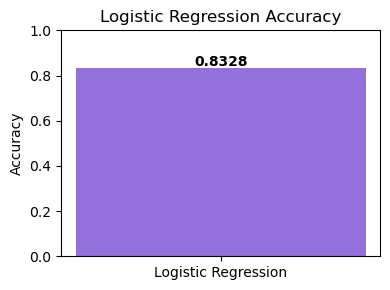

In [17]:
plt.figure(figsize=(4, 3))
plt.bar(['Logistic Regression'], [acc], color='mediumpurple')
plt.ylim(0, 1)
plt.title("Logistic Regression Accuracy")
plt.ylabel("Accuracy")
plt.text(0, acc + 0.01, f"{acc:.4f}", ha='center', fontweight='bold')
plt.tight_layout(); plt.show()
